# Does the predictor identify the dynamics?

We train the same architecture on three conditions with identical observation marginals: static, cyclic, and independent. Only the future window paired with each current window changes.

The main question is not how far training loss falls, but which operator best explains the learned predictor's action:

$$E_d(M,A)=\frac{\lVert MA-AK_d\rVert_F}{\lVert A\rVert_F}.$$

For every model, we compare all three candidates. Action and spectral identification must each be correct in at least 8/10 seeds per condition. Design and assumptions are summarized in `docs/EXPERIMENT.md`.

In [1]:
# ruff: noqa: E402, E501, I001
import json
import sys
from math import comb
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display

from koopman_jepa.config import DataConfig, ExperimentConfig, ModelConfig, TrainConfig, validate_config
from koopman_jepa.model import TemporalJEPA
from koopman_jepa.phase_analysis import evaluate_phase_operator_candidates, evaluate_phase_operator_diagnostics, evaluate_phase_representation
from koopman_jepa.phase_data import PhaseWindowConfig, make_phase_tensor_dataset_splits
from koopman_jepa.training import collect_paired_embeddings, select_device, set_seed, train_model

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
CONFIG_PATH = ROOT / "configs" / "three_dynamics.yaml"
with CONFIG_PATH.open(encoding="utf-8") as handle:
    raw = yaml.safe_load(handle)

dynamics = tuple(raw["dynamics"])
seeds = tuple(raw["seeds"])
candidates = tuple(raw["operator_identification"]["candidates"])
minimum_correct = raw["operator_identification"]["minimum_correct_seeds_per_dynamics"]
chance_probability = raw["operator_identification"]["chance_probability"]
rollout_horizons = tuple(raw["diagnostics"]["rollout_horizons"])
required_active_rank = raw["diagnostics"]["required_active_rank"]
assert dynamics == candidates == ("static", "cyclic", "independent")
assert seeds == tuple(range(1, 11))
null_tail = sum(comb(len(seeds), k) * chance_probability**k * (1.0 - chance_probability)**(len(seeds) - k) for k in range(minimum_correct, len(seeds) + 1))
assert np.isclose(null_tail, raw["operator_identification"]["one_sided_tail_probability_at_threshold"])
emission_config = PhaseWindowConfig(**raw["emission"], repeats_per_transition=1)
model_raw = raw["model"]
print(json.dumps({"config": CONFIG_PATH.name, "dynamics": dynamics, "seeds": seeds, "minimum_correct": minimum_correct, "null_tail": null_tail, "test_constructed": False}, indent=2))

{
  "config": "three_dynamics.yaml",
  "dynamics": [
    "static",
    "cyclic",
    "independent"
  ],
  "seeds": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10
  ],
  "minimum_correct": 8,
  "null_tail": 0.0034039526494944864,
  "test_constructed": false
}


## Controlled comparison

Within each seed, all three models start from the same weights. Current and future window banks are identical; only temporal pairing changes. The alignment matrix $A$ is estimated from training phases and used to compare the action of $M$ against all three candidate operators.

A seed without active rank 3 counts as unidentified: a three-dimensional spectrum cannot be claimed if the representation discarded a mode.

In [3]:
def make_experiment_config(seed):
    config = ExperimentConfig(
        data=DataConfig(context_length=emission_config.window_length),
        model=ModelConfig(latent_dim=model_raw["latent_dim"], channels=model_raw["channels"], predictor_init=model_raw["predictor_init"]),
        train=TrainConfig(seed=seed, **raw["train"]),
    )
    validate_config(config)
    return config

def make_model(device):
    return TemporalJEPA(
        latent_dim=model_raw["latent_dim"],
        channels=model_raw["channels"],
        predictor_init=model_raw["predictor_init"],
        pooling=model_raw["pooling"],
        input_length=emission_config.window_length,
    ).to(device)

def evaluate_run(model, train_dataset, validation_dataset, config, dynamics_name, seed, history):
    device = select_device(config.train.device)
    train_current, _, _, train_phase_pairs = collect_paired_embeddings(model, train_dataset, config.train.batch_size, device)
    val_current, val_future_online, val_future_target, val_phase_pairs = collect_paired_embeddings(model, validation_dataset, config.train.batch_size, device)
    predictor = model.predictor.matrix.detach().cpu().numpy()
    representation = evaluate_phase_representation(
        train_current, train_phase_pairs[:, 0], val_current, val_phase_pairs[:, 0], predictor, dynamics_name, seed
    )
    comparison = evaluate_phase_operator_candidates(
        train_current, train_phase_pairs[:, 0], predictor, candidates, rollout_horizons
    )
    diagnostic = evaluate_phase_operator_diagnostics(
        val_current, val_future_online, val_future_target, val_phase_pairs[:, 0], val_phase_pairs[:, 1], predictor, dynamics_name
    )
    full_rank = comparison["active_rank"] == required_active_rank
    spectral_errors = comparison["spectral_mean_errors"]
    return {
        "seed": seed,
        "dynamics": dynamics_name,
        "full_rank": full_rank,
        "action_correct": full_rank and comparison["predicted_action_dynamics"] == dynamics_name,
        "spectrum_correct": full_rank and comparison["predicted_spectral_dynamics"] == dynamics_name,
        "predicted_action": comparison["predicted_action_dynamics"],
        "predicted_spectrum": comparison["predicted_spectral_dynamics"],
        "action_errors": comparison["action_errors"],
        "spectral_errors": spectral_errors,
        "action_margin": comparison["action_margin"],
        "spectrum_margin": comparison["spectrum_margin"],
        "rollout_errors": comparison["rollout_errors"],
        "active_eigenvalues": comparison["active_eigenvalues"],
        "effective_rank": representation["effective_rank"],
        "phase_probe_accuracy": representation["linear_probe_accuracy"],
        "phase_alignment_error": representation["phase_alignment_error"],
        "active_invariance_error": representation["active_invariance_error"],
        "predictor_vs_posthoc_online_error": diagnostic["predictor_vs_posthoc_online_error"],
        "final_prediction_loss": history[-1]["val_prediction_loss"],
        "final_total_loss": history[-1]["val_loss"],
    }

In [4]:
results = []
histories = {}
for seed in seeds:
    config = make_experiment_config(seed)
    splits = make_phase_tensor_dataset_splits(
        emission_config,
        train_repeats_per_transition=raw["splits"]["train_repeats_per_transition"],
        validation_repeats_per_transition=raw["splits"]["validation_repeats_per_transition"],
        seed=seed,
    )
    assert splits.test is None
    assert len({len(splits.train[name]) for name in dynamics}) == 1
    assert len({len(splits.validation[name]) for name in dynamics}) == 1
    for dynamics_name in dynamics:
        set_seed(seed)
        device = select_device(config.train.device)
        model = make_model(device)
        history = train_model(model, splits.train[dynamics_name], splits.validation[dynamics_name], config, device)
        assert all(np.isfinite(value) for row in history for value in row.values())
        histories[(seed, dynamics_name)] = history
        result = evaluate_run(model, splits.train[dynamics_name], splits.validation[dynamics_name], config, dynamics_name, seed, history)
        results.append(result)
        print(f"seed={seed:02d} true={dynamics_name:11s} action={result['predicted_action']:11s} spectrum={str(result['predicted_spectrum']):11s} rank3={result['full_rank']}")

assert len(results) == len(seeds) * len(dynamics)

epoch=001 train=4.205738 val=3.944427


epoch=012 train=0.903767 val=3.730799


epoch=024 train=0.407600 val=3.265403


epoch=036 train=0.288287 val=3.161285


epoch=048 train=0.293832 val=3.142993


...

epoch=012 train=1.261887 val=1.229781


epoch=024 train=1.188008 val=1.159934


epoch=036 train=1.174450 val=1.140763


epoch=048 train=1.162083 val=1.136689


epoch=060 train=1.155446 val=1.135963
seed=10 true=independent action=independent spectrum=independent rank3=True


In [5]:
summary = {}
for dynamics_name in dynamics:
    subset = [row for row in results if row["dynamics"] == dynamics_name]
    action_correct = sum(row["action_correct"] for row in subset)
    spectrum_correct = sum(row["spectrum_correct"] for row in subset)
    full_rank = sum(row["full_rank"] for row in subset)
    summary[dynamics_name] = {
        "full_rank_seeds": full_rank,
        "correct_action_seeds": action_correct,
        "correct_spectrum_seeds": spectrum_correct,
        "median_correct_action_error": float(np.median([row["action_errors"][dynamics_name] for row in subset])),
        "median_action_margin": float(np.median([row["action_margin"] for row in subset])),
        "median_spectrum_margin": float(np.nanmedian([row["spectrum_margin"] if row["spectrum_margin"] is not None else np.nan for row in subset])),
        "median_effective_rank": float(np.median([row["effective_rank"] for row in subset])),
        "median_phase_probe_accuracy": float(np.median([row["phase_probe_accuracy"] for row in subset])),
        "operator_identification_passed": action_correct >= minimum_correct and spectrum_correct >= minimum_correct,
    }
global_operator_result = all(values["operator_identification_passed"] for values in summary.values())
display(Markdown("## Resumen agregado"))
print(json.dumps({"conditions": summary, "global_operator_result": global_operator_result, "loss_used_for_decision": False}, indent=2))

## Resumen agregado

{
  "conditions": {
    "static": {
      "full_rank_seeds": 10,
      "correct_action_seeds": 10,
      "correct_spectrum_seeds": 10,
      "median_correct_action_error": 0.14194779455601902,
      "median_action_margin": 0.8060667970086041,
      "median_spectrum_margin": 0.5943480233351394,
      "median_effective_rank": 2.7072223331631875,
      "median_phase_probe_accuracy": 1.0,
      "operator_identification_passed": true
    },
    "cyclic": {
      "full_rank_seeds": 10,
      "correct_action_seeds": 10,
      "correct_spectrum_seeds": 10,
      "median_correct_action_error": 0.06822191509801676,
      "median_action_margin": 0.876887274440836,
      "median_spectrum_margin": 0.887688212271039,
      "median_effective_rank": 2.810831580138041,
      "median_phase_probe_accuracy": 1.0,
      "operator_identification_passed": true
    },
    "independent": {
      "full_rank_seeds": 10,
      "correct_action_seeds": 10,
      "correct_spectrum_seeds": 10,
      "median_correct_a

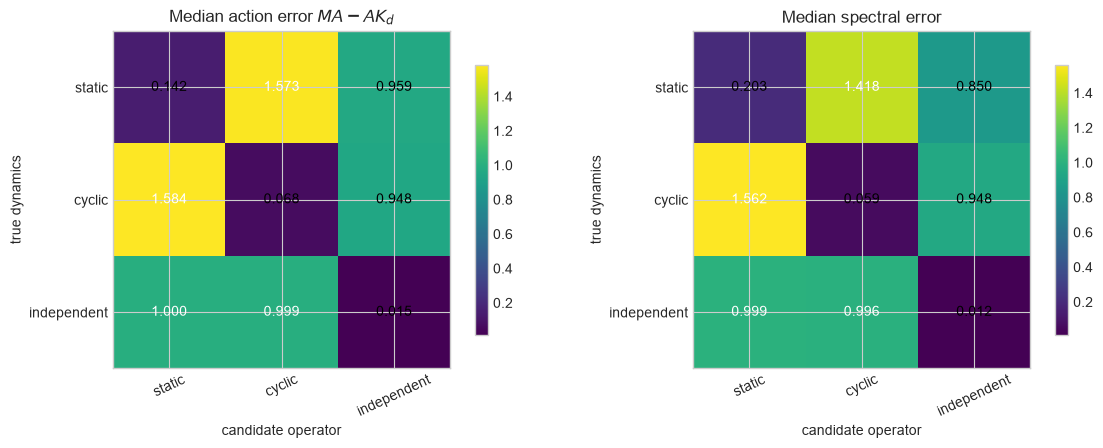

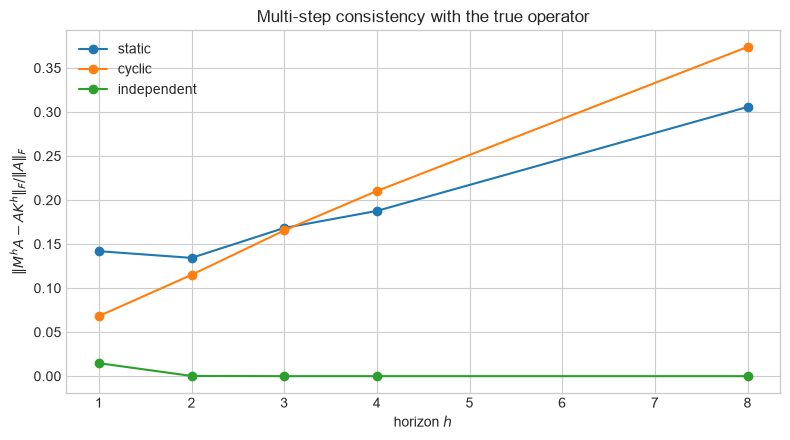

In [6]:
action_matrix = np.array([[np.median([row["action_errors"][candidate] for row in results if row["dynamics"] == truth]) for candidate in candidates] for truth in dynamics])
spectral_matrix = np.array([[np.nanmedian([row["spectral_errors"][candidate] if row["spectral_errors"] is not None else np.nan for row in results if row["dynamics"] == truth]) for candidate in candidates] for truth in dynamics])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for axis, matrix, title in zip(axes, (action_matrix, spectral_matrix), ("Median action error $MA-AK_d$", "Median spectral error"), strict=True):
    image = axis.imshow(matrix, cmap="viridis")
    axis.set_xticks(range(len(candidates)), candidates, rotation=25)
    axis.set_yticks(range(len(dynamics)), dynamics)
    axis.set_xlabel("candidate operator")
    axis.set_ylabel("true dynamics")
    axis.set_title(title)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            axis.text(column_index, row_index, f"{matrix[row_index, column_index]:.3f}", ha="center", va="center", color="white" if matrix[row_index, column_index] > np.nanmedian(matrix) else "black")
    fig.colorbar(image, ax=axis, shrink=0.8)
fig.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(8, 4.5))
for dynamics_name in dynamics:
    median_rollout = [np.median([row["rollout_errors"][dynamics_name][horizon] for row in results if row["dynamics"] == dynamics_name]) for horizon in rollout_horizons]
    axis.plot(rollout_horizons, median_rollout, marker="o", label=dynamics_name)
axis.set_xlabel("horizon $h$")
axis.set_ylabel(r"$\Vert M^hA-AK^h\Vert_F/\Vert A\Vert_F$")
axis.set_title("Multi-step consistency with the true operator")
axis.legend()
fig.tight_layout()
plt.show()

In [7]:
lines = ["## Reading the results", ""]
for dynamics_name in dynamics:
    values = summary[dynamics_name]
    lines.append(f"- **{dynamics_name}**: action {values['correct_action_seeds']}/10, spectrum {values['correct_spectrum_seeds']}/10, and full rank {values['full_rank_seeds']}/10. Median correct action error is {values['median_correct_action_error']:.3f}; margin to the next candidate is {values['median_action_margin']:.3f}.")
lines.extend(["", f"**Primary conclusion:** {'all three conditions pass the predeclared criterion; the predictor identifies the dynamics.' if global_operator_result else 'at least one condition does not reach the predeclared criterion.'}", "", "Total training loss does not enter this conclusion. The plots show a low diagonal: each row has the same observation marginals but a different temporal pairing. The rollout also shows whether a small one-step error remains bounded or accumulates.", "", "Scope: validation result in a synthetic four-state system; it does not establish general Koopman recovery."])
display(Markdown("\n".join(lines)))

## Reading the results

- **static**: action 10/10, spectrum 10/10, and full rank 10/10. Median correct action error is 0.142; margin to the next candidate is 0.806.
- **cyclic**: action 10/10, spectrum 10/10, and full rank 10/10. Median correct action error is 0.068; margin to the next candidate is 0.877.
- **independent**: action 10/10, spectrum 10/10, and full rank 10/10. Median correct action error is 0.015; margin to the next candidate is 0.981.

**Primary conclusion:** all three conditions pass the predeclared criterion; the predictor identifies the dynamics.

Total training loss does not enter this conclusion. The plots show a low diagonal: each row has the same observation marginals but a different temporal pairing. The rollout also shows whether a small one-step error remains bounded or accumulates.

Scope: validation result in a synthetic four-state system; it does not establish general Koopman recovery.